In [48]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
NOTIONAL_CONTRACTS = {
    "atm_call": 1,
    "atm_put": 1,
    "otm_call": 1,
    "otm_put": 1
}

In [50]:
def import_data():
    session_signals = pd.read_csv('data/session_signals.csv')
    options_df = pd.read_csv("data/options_df.csv")
    btc_prices = pd.read_csv('data/btc_prices.csv')
    btc_prices.rename(columns={'Unnamed: 0': 'time'}, inplace=True)
    return session_signals, options_df, btc_prices

In [51]:
def construct_trades(session_signals, options_df):
    positive_signals = session_signals[session_signals['signal']]
    trades_df = options_df[options_df['session_start'].isin(positive_signals['session_start'])].copy()

    trades_df['position'] = np.select(
        [
            trades_df['leg'].str.startswith('atm'),
            trades_df['leg'].str.startswith('otm')
        ],
        ['short', 'long'],
        default=None
    )

    trades_df['contracts'] = trades_df['leg'].map(NOTIONAL_CONTRACTS)

    if trades_df['contracts'].isna().any():
        missing = trades_df.loc[trades_df['contracts'].isna(), 'leg'].unique()
        raise ValueError(f"Unmapped legs found in NOTIONAL_CONTRACTS: {missing}")

    if trades_df['position'].isna().any():
        bad = trades_df.loc[trades_df['position'].isna(), 'leg'].unique()
        raise ValueError(f"Unclassified legs: {bad}")

    cols = [
        'session_start', 'session_type', 'leg', 'strike', 'option_type',
        'position', 'entry_price', 'expiry', 'contracts'
    ]

    trades_df = trades_df[cols]
    return trades_df

In [52]:
def calculate_exit_price_and_pnl(trades_df, btc_prices):
    btc_prices_keyed = btc_prices[['time', 'close']].rename(
        columns={'time': 'expiry', 'close': 'spot_at_expiry'}
    )
    
    trades_df = trades_df.merge(
        btc_prices_keyed,
        on='expiry',
        how='left'
    )

    if trades_df['spot_at_expiry'].isna().any():
        missing = trades_df.loc[trades_df['spot_at_expiry'].isna(), 'expiry'].unique()
        raise ValueError(f"Missing BTC prices for expiries: {missing}")
    
    spot = trades_df['spot_at_expiry']
    strike = trades_df['strike']

    call_payoff = np.maximum(spot - strike, 0)
    put_payoff  = np.maximum(strike - spot, 0)

    trades_df['exit_price'] = np.select(
        [
            trades_df['option_type'] == 'C',
            trades_df['option_type'] == 'P'
        ],
        [
            call_payoff,
            put_payoff
        ],
        default=np.nan
    )

    trades_df['position_sign'] = trades_df['position'].map({'short': -1, 'long': 1})

    trades_df['pnl'] = (
        (trades_df['entry_price'] * trades_df['spot_at_expiry'] - trades_df['exit_price'])
        * trades_df['contracts']
        * trades_df['position_sign']
    )

    trades_df.drop(columns=['position_sign'], inplace=True)

    return trades_df

In [53]:
def summarise_pnl(trades_df):
    trades_df['premium_component'] = np.where(
        trades_df['position'] == 'short',
        trades_df['entry_price'],
        0
    )

    trades_df['hedge_component'] = np.where(
        trades_df['position'] == 'long',
        trades_df['entry_price'],
        0
    )

    agg = trades_df.groupby('session_start').agg(
        gross_pnl_usd=('pnl', 'sum'),
        premium_sum=('premium_component', 'sum'),
        hedge_sum=('hedge_component', 'sum'),
        spot_at_expiry=('spot_at_expiry', 'first')  # assumes constant per session
    )

    agg = agg.sort_values('session_start')

    agg['premiums_received'] = agg['premium_sum'] * agg['spot_at_expiry']
    agg['hedge_cost'] = agg['hedge_sum'] * agg['spot_at_expiry']
    agg['net_entry_premium'] = agg['premiums_received'] - agg['hedge_cost']

    agg['cumulative_pnl_usd'] = agg['gross_pnl_usd'].cumsum()

    pnl_df = agg.reset_index()[[
        'session_start',
        'gross_pnl_usd',
        'premiums_received',
        'hedge_cost',
        'net_entry_premium',
        'cumulative_pnl_usd'
    ]]
    
    return pnl_df

In [201]:
session_signals, options_df, btc_prices = import_data()

In [202]:
trades_df = construct_trades(session_signals, options_df)
trades_df = calculate_exit_price_and_pnl(trades_df, btc_prices)
len(trades_df)
trades_df.tail()

,session_start,session_type,leg,strike,option_type,position,entry_price,expiry,contracts,spot_at_expiry,exit_price,pnl
71,2025-12-21 08:00:00+00:00,weekend,otm_put,82000.0,P,long,0.0001,2025-12-22 00:00:00+00:00,1,88600.00,0.00,8.860000
72,2025-12-28 08:00:00+00:00,weekend,atm_call,88000.0,C,short,0.0055,2025-12-29 00:00:00+00:00,1,88222.05,222.05,-263.171275
73,2025-12-28 08:00:00+00:00,weekend,atm_put,88000.0,P,short,0.0085,2025-12-29 00:00:00+00:00,1,88222.05,0.00,-749.887425
74,2025-12-28 08:00:00+00:00,weekend,otm_call,92000.0,C,long,0.0001,2025-12-29 00:00:00+00:00,1,88222.05,0.00,8.822205
75,2025-12-28 08:00:00+00:00,weekend,otm_put,84000.0,P,long,0.0001,2025-12-29 00:00:00+00:00,1,88222.05,0.00,8.822205


In [203]:
pnl_df = summarise_pnl(trades_df)
pnl_df

,session_start,gross_pnl_usd,premiums_received,hedge_cost,net_entry_premium,cumulative_pnl_usd
0,2025-01-02 08:00:00+00:00,-1344.036472,2109.055606,19.349134,2089.706472,-1344.036472
1,2025-01-04 08:00:00+00:00,-591.630942,854.373234,58.922292,795.450942,-1935.667414
2,2025-01-06 08:00:00+00:00,1336.843152,1786.624700,30.627852,1755.996848,-598.824262
3,2025-01-15 08:00:00+00:00,407.180471,2496.851750,29.962221,2466.889529,-191.643791
4,2025-01-18 08:00:00+00:00,-263.485693,1300.198875,20.803182,1279.395693,-455.129484
5,2025-01-27 08:00:00+00:00,-133.873620,3106.115425,132.391805,2973.723620,-589.003104
6,2025-02-23 08:00:00+00:00,-1174.314172,1193.565224,19.251052,1174.314172,-1763.317276
7,2025-02-28 08:00:00+00:00,1395.091448,2975.316770,58.668218,2916.648552,-368.225828
8,2025-03-11 08:00:00+00:00,-1100.047192,2896.125050,49.647858,2846.477192,-1468.273020
9,2025-03-12 08:00:00+00:00,-1604.860350,2544.134625,25.024275,2519.110350,-3073.133370


#### Subtask 8

In [199]:
def compute_stats(session_signals, pnl_df):
    session_signals = session_signals.copy()

    if session_signals["session_start"].dtype == object:
        session_signals["session_start"] = pd.to_datetime(
            session_signals["session_start"],
            utc=True
        )

    # Ensure session_dow exists and is lowercase
    if "session_dow" not in session_signals.columns:
        session_signals["session_dow"] = (
            session_signals["session_start"]
            .dt.day_name()
            .str.lower()
        )
    else:
        session_signals["session_dow"] = session_signals["session_dow"].str.lower()

    weekend_vrp = session_signals.loc[
        session_signals["session_type"] == "weekend",
        "vrp"
    ].dropna()

    weekday_vrp = session_signals.loc[
        session_signals["session_type"] == "weekday",
        "vrp"
    ].dropna()

    mean_vrp_weekend = weekend_vrp.mean()
    mean_vrp_weekday = weekday_vrp.mean()

    # One-sided: is mean VRP > 0?
    t_stat_weekend, p_value_weekend = stats.ttest_1samp(
        weekend_vrp,
        0.0,
        alternative="greater"
    )

    t_stat_weekday, p_value_weekday = stats.ttest_1samp(
        weekday_vrp,
        0.0,
        alternative="greater"
    )

    # Two-sided: is weekend VRP != weekday VRP?
    t_stat_diff, p_value_diff = stats.ttest_ind(
        weekend_vrp,
        weekday_vrp,
        equal_var=False
    )

    pnl_typed = pnl_df.merge(
        session_signals[
            ["session_start", "session_type", "session_dow"]
        ].astype({"session_start": str}),
        left_on=pnl_df["session_start"].astype(str),
        right_on="session_start",
        how="left",
        suffixes=("", "_y")
    ).drop(columns=["key_0", "session_start_y"], errors="ignore")

    def sharpe(series, ann_factor):
        s = series.dropna()
        if len(s) < 2 or s.std(ddof=1) == 0:
            return np.nan
        return s.mean() / s.std(ddof=1) * np.sqrt(ann_factor)

    weekend_pnl = pnl_typed.loc[
        pnl_typed["session_type"] == "weekend",
        "gross_pnl_usd"
    ]

    weekday_pnl = pnl_typed.loc[
        pnl_typed["session_type"] == "weekday",
        "gross_pnl_usd"
    ]

    sharpe_weekend = sharpe(weekend_pnl, 52)
    sharpe_weekday = sharpe(weekday_pnl, 104)

    # -----------------------------
    # Day-of-week stats
    # -----------------------------
    day_order = [
        "monday", "tuesday", "wednesday", "thursday",
        "friday", "saturday", "sunday"
    ]

    dow_results = {}

    for day in day_order:
        day_vrp = session_signals.loc[
            session_signals["session_dow"] == day,
            "vrp"
        ].dropna()

        day_pnl = pnl_typed.loc[
            pnl_typed["session_dow"] == day,
            "gross_pnl_usd"
        ].dropna()

        if len(day_vrp) >= 2:
            t_day, p_day = stats.ttest_1samp(
                day_vrp,
                0.0,
                alternative="greater"
            )
        else:
            t_day, p_day = np.nan, np.nan

        dow_results[day] = {
            "n_vrp": len(day_vrp),
            "mean_vrp": day_vrp.mean(),
            "t_stat_vrp_gt_0": t_day,
            "p_value_vrp_gt_0": p_day,
            "n_pnl": len(day_pnl),
            "mean_pnl": day_pnl.mean(),
            "total_pnl": day_pnl.sum(),
            "sharpe": sharpe(day_pnl, 52),
        }

    stats_results = {
        "mean_vrp_weekend": mean_vrp_weekend,
        "mean_vrp_weekday": mean_vrp_weekday,
        "t_stat_weekend": t_stat_weekend,
        "p_value_weekend": p_value_weekend,
        "t_stat_weekday": t_stat_weekday,
        "p_value_weekday": p_value_weekday,
        "t_stat_diff": t_stat_diff,
        "p_value_diff": p_value_diff,
        "sharpe_weekend": sharpe_weekend,
        "sharpe_weekday": sharpe_weekday,
        "dow_results": dow_results,
    }

    print("=== VRP Statistical Analysis ===")
    print(f"n weekend sessions: {len(weekend_vrp)}, n weekday sessions: {len(weekday_vrp)}")
    print(f"Mean VRP weekend: {mean_vrp_weekend:.4f}")
    print(f"Mean VRP weekday: {mean_vrp_weekday:.4f}")
    print()

    print("One-sided one-sample t-test (H0: mean VRP <= 0, H1: mean VRP > 0):")
    print(f"  Weekend: t = {t_stat_weekend:.3f}, p = {p_value_weekend:.4f}")
    print(f"  Weekday: t = {t_stat_weekday:.3f}, p = {p_value_weekday:.4f}")
    print()

    print("Two-sided Welch t-test (H0: weekend VRP = weekday VRP):")
    print(f"  t = {t_stat_diff:.3f}, p = {p_value_diff:.4f}")
    print()

    print("Annualised Sharpe (gross_pnl_usd):")
    print(f"  Weekend (sqrt(52)):  {sharpe_weekend:.3f}  (n={len(weekend_pnl.dropna())})")
    print(f"  Weekday (sqrt(104)): {sharpe_weekday:.3f}  (n={len(weekday_pnl.dropna())})")
    print()

    print("=== Day-of-week breakdown ===")
    for day in day_order:
        r = dow_results[day]
        print(
            f"  {day.capitalize():<9} | "
            f"Mean VRP: {r['mean_vrp']:>8.4f} | "
            f"t: {r['t_stat_vrp_gt_0']:>7.3f} | "
            f"p: {r['p_value_vrp_gt_0']:>7.4f} | "
            f"Sharpe sqrt(52): {r['sharpe']:>7.3f} | "
            f"Mean PnL: {r['mean_pnl']:>9.2f} | "
            f"Total PnL: {r['total_pnl']:>10.2f} | "
            f"n={r['n_pnl']}"
        )

    return stats_results

In [200]:
stats_results = compute_stats(session_signals, pnl_df)
stats_results

=== VRP Statistical Analysis ===
n weekend sessions: 106, n weekday sessions: 265
Mean VRP weekend: -0.0323
Mean VRP weekday: -0.0050

One-sided one-sample t-test (H0: mean VRP <= 0, H1: mean VRP > 0):
  Weekend: t = -2.592, p = 0.9946
  Weekday: t = -0.533, p = 0.7029

Two-sided Welch t-test (H0: weekend VRP = weekday VRP):
  t = -1.751, p = 0.0813

Annualised Sharpe (gross_pnl_usd):
  Weekend (sqrt(52)):  -0.427  (n=20)
  Weekday (sqrt(104)): -1.145  (n=72)

=== Day-of-week breakdown ===
  Monday    | Mean VRP:  -0.0347 | t:  -1.206 | p:  0.8834 | Sharpe sqrt(52):  -0.583 | Mean PnL:   -100.69 | Total PnL:   -1409.72 | n=14
  Tuesday   | Mean VRP:  -0.0036 | t:  -0.201 | p:  0.5792 | Sharpe sqrt(52):   0.702 | Mean PnL:    139.47 | Total PnL:    1534.12 | n=11
  Wednesday | Mean VRP:   0.0260 | t:   1.733 | p:  0.0444 | Sharpe sqrt(52):  -3.362 | Mean PnL:   -457.40 | Total PnL:   -8233.26 | n=18
  Thursday  | Mean VRP:  -0.0341 | t:  -1.503 | p:  0.9305 | Sharpe sqrt(52):  -0.290 | 

{'mean_vrp_weekend': -0.03234890672434395,
 'mean_vrp_weekday': -0.005006405702678494,
 't_stat_weekend': -2.5922140537543417,
 'p_value_weekend': 0.9945530219873164,
 't_stat_weekday': -0.5334287764314853,
 'p_value_weekday': 0.7029072002239796,
 't_stat_diff': -1.7510835210771782,
 'p_value_diff': 0.08127443050564562,
 'sharpe_weekend': -0.4273639795989466,
 'sharpe_weekday': -1.1450363456692352,
 'dow_results': {'monday': {'n_vrp': 53,
   'mean_vrp': -0.03468149463063773,
   't_stat_vrp_gt_0': -1.2064169998625343,
   'p_value_vrp_gt_0': 0.8834415731266025,
   'n_pnl': 14,
   'mean_pnl': -100.69453107142795,
   'total_pnl': -1409.7234349999912,
   'sharpe': -0.5828284362080977},
  'tuesday': {'n_vrp': 53,
   'mean_vrp': -0.003561460961250953,
   't_stat_vrp_gt_0': -0.20080488624449402,
   'p_value_vrp_gt_0': 0.579182747647441,
   'n_pnl': 11,
   'mean_pnl': 139.46557227272558,
   'total_pnl': 1534.1212949999813,
   'sharpe': 0.7018831521308394},
  'wednesday': {'n_vrp': 54,
   'mean_

#### Subtask 9

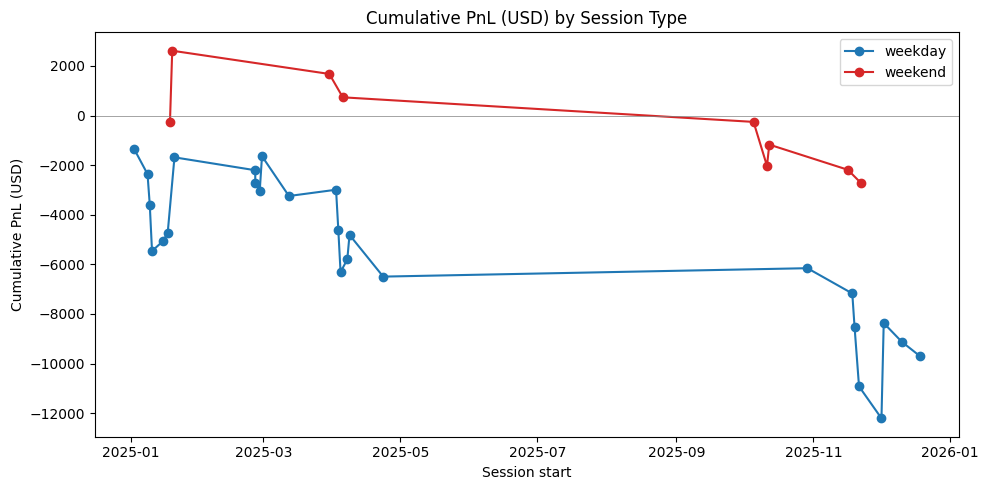

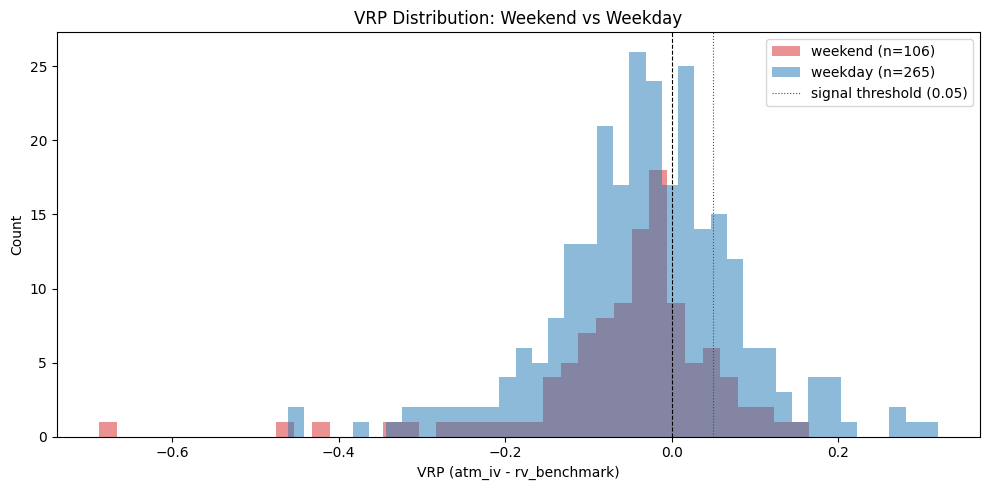

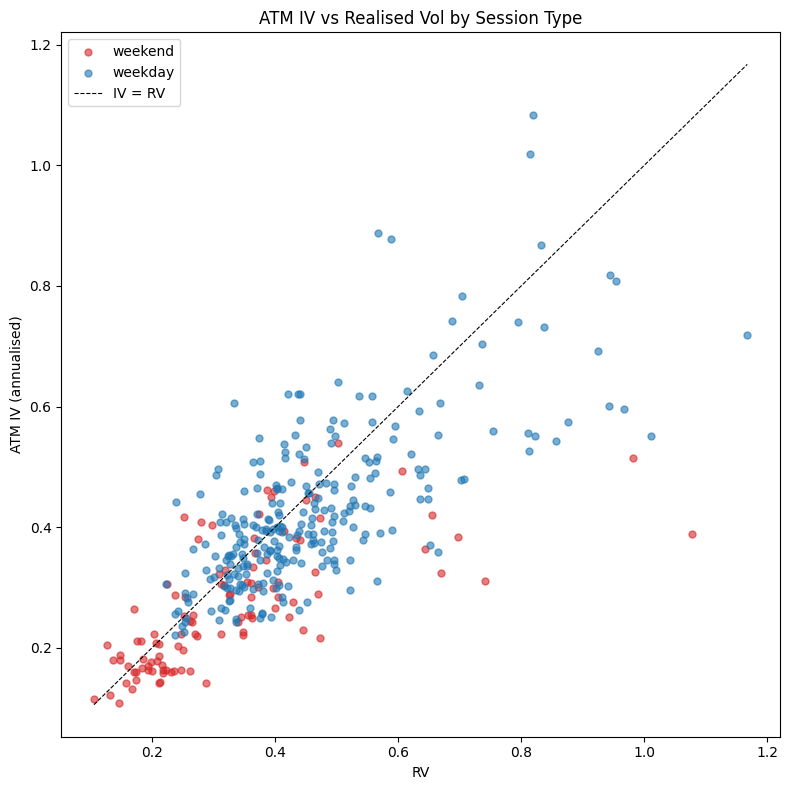

C:\Users\henry\AppData\Local\Temp\ipykernel_28596\3963606720.py:51: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sig['month'] = sig['session_start'].dt.to_period('M').astype(str)


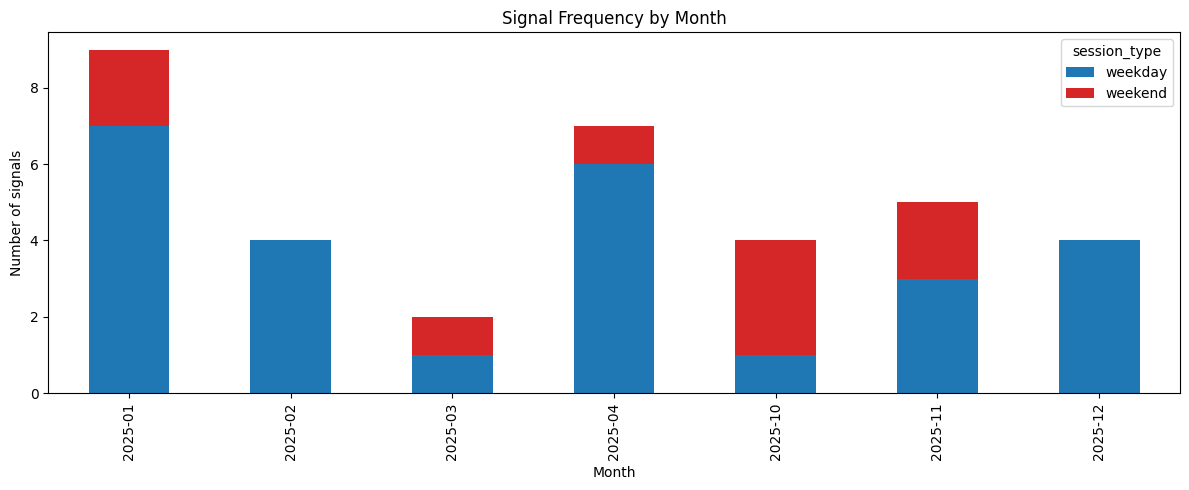

In [190]:
def make_charts(session_signals, trades_df, pnl_df):
    ss = session_signals.copy()
    ss['session_start'] = pd.to_datetime(ss['session_start'], utc=True)

    pnl = pnl_df.copy()
    pnl['session_start'] = pd.to_datetime(pnl['session_start'], utc=True)
    pnl = pnl.merge(ss[['session_start', 'session_type']], on='session_start', how='left')
    pnl = pnl.sort_values('session_start')

    palette = {'weekend': '#d62728', 'weekday': '#1f77b4'}

    # 1. Cumulative PnL (USD) by session type
    fig, ax = plt.subplots(figsize=(10, 5))
    for stype, grp in pnl.groupby('session_type'):
        grp = grp.sort_values('session_start').copy()
        grp['cum'] = grp['gross_pnl_usd'].cumsum()
        ax.plot(grp['session_start'], grp['cum'], marker='o', label=stype, color=palette.get(stype))
    ax.set_title('Cumulative PnL (USD) by Session Type')
    ax.set_xlabel('Session start'); ax.set_ylabel('Cumulative PnL (USD)')
    ax.axhline(0, color='grey', lw=0.5); ax.legend(); fig.tight_layout()
    plt.show()

    # 2. VRP distribution histogram, weekend vs weekday overlaid
    fig, ax = plt.subplots(figsize=(10, 5))
    for stype in ['weekend', 'weekday']:
        vals = ss.loc[ss['session_type'] == stype, 'vrp'].dropna()
        ax.hist(vals, bins=40, alpha=0.5, label=f'{stype} (n={len(vals)})', color=palette[stype])
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.axvline(0.05, color='green', lw=0.8, linestyle=':', label='signal threshold (0.05)')
    ax.set_title('VRP Distribution: Weekend vs Weekday')
    ax.set_xlabel('VRP (atm_iv - rv_benchmark)'); ax.set_ylabel('Count')
    ax.legend(); fig.tight_layout()
    plt.show()

    # 3. IV vs RV scatter, coloured by session type
    fig, ax = plt.subplots(figsize=(8, 8))
    for stype in ['weekend', 'weekday']:
        sub = ss[ss['session_type'] == stype]
        ax.scatter(sub['rv_benchmark'], sub['atm_iv'], alpha=0.6, label=stype,
                   color=palette[stype], s=25)
    lo = min(ss['rv_benchmark'].min(), ss['atm_iv'].min())
    hi = max(ss['rv_benchmark'].max(), ss['atm_iv'].max())
    ax.plot([lo, hi], [lo, hi], color='black', lw=0.8, linestyle='--', label='IV = RV')
    ax.set_title('ATM IV vs Realised Vol by Session Type')
    ax.set_xlabel('RV'); ax.set_ylabel('ATM IV (annualised)')
    ax.legend(); fig.tight_layout()
    plt.show()

    # 4. Signal frequency by month
    sig = ss[ss['signal'].astype(bool)].copy()
    sig['month'] = sig['session_start'].dt.to_period('M').astype(str)
    counts = sig.groupby(['month', 'session_type']).size().unstack(fill_value=0)
    fig, ax = plt.subplots(figsize=(12, 5))
    counts.plot(kind='bar', stacked=True, ax=ax,
                color=[palette.get(c, 'grey') for c in counts.columns])
    ax.set_title('Signal Frequency by Month')
    ax.set_xlabel('Month'); ax.set_ylabel('Number of signals')
    ax.legend(title='session_type'); fig.tight_layout()
    plt.show()

make_charts(session_signals, trades_df, pnl_df)

In [173]:
# CSV outputs
session_signals.to_csv('data/session_signals.csv', index=False)
trades_df.to_csv('data/trades_df.csv', index=False)
pnl_df.to_csv('data/pnl_df.csv', index=False)
print("Wrote: data/session_signals.csv, data/trades_df.csv, data/pnl_df.csv")

Wrote: data/session_signals.csv, data/trades_df.csv, data/pnl_df.csv


In [174]:
session_signals = pd.read_csv('data/session_signals.csv')
session_signals.head(10)

,session_start,session_close,session_type,session_dow,atm_iv,iv_52w_low,iv_52w_high,iv_rank,rv_5d,rv_1d,dow_multiplier,rv_benchmark,dow_multiplier_yesterday,vrp,vrp_ratio,signal
0,2025-01-01 08:00:00+00:00,2025-01-02 08:00:00+00:00,weekday,wednesday,0.43040,0.43040,0.43040,50.000000,0.445885,0.443133,1.030909,0.384248,1.188893,0.046152,1.120109,False
1,2025-01-02 08:00:00+00:00,2025-01-03 08:00:00+00:00,weekday,thursday,0.53770,0.43040,0.53770,99.999068,0.428175,0.278075,0.977428,0.263649,1.030909,0.274051,2.039456,True
2,2025-01-03 08:00:00+00:00,2025-01-04 08:00:00+00:00,weekday,friday,0.40305,0.40305,0.53770,0.000743,0.453635,0.369986,0.876929,0.331945,0.977428,0.071105,1.214209,False
3,2025-01-04 08:00:00+00:00,2025-01-05 08:00:00+00:00,weekend,saturday,0.20875,0.20875,0.20875,50.000000,0.450444,0.254323,0.515801,0.149590,0.876929,0.059160,1.395477,False
4,2025-01-05 08:00:00+00:00,2025-01-06 08:00:00+00:00,weekend,sunday,0.28990,0.20875,0.28990,99.998768,0.319245,0.185265,0.816020,0.293098,0.515801,-0.003198,0.989091,False
5,2025-01-06 08:00:00+00:00,2025-01-07 08:00:00+00:00,weekday,monday,0.45750,0.40305,0.53770,40.438315,0.267061,0.208302,1.147363,0.292883,0.816020,0.164617,1.562056,True
6,2025-01-06 08:00:00+00:00,2025-01-07 08:00:00+00:00,weekday,monday,0.45750,0.40305,0.53770,40.438315,0.267050,0.204254,1.151038,0.278831,0.843175,0.178669,1.640777,True
7,2025-01-07 08:00:00+00:00,2025-01-08 08:00:00+00:00,weekday,tuesday,0.42500,0.40305,0.53770,16.302023,0.297373,0.422425,1.252925,0.459817,1.151038,-0.034817,0.924281,False
8,2025-01-08 08:00:00+00:00,2025-01-09 08:00:00+00:00,weekday,wednesday,0.50895,0.40305,0.53770,78.647922,0.356420,0.566925,1.041904,0.471442,1.252925,0.037508,1.079560,False
9,2025-01-09 08:00:00+00:00,2025-01-10 08:00:00+00:00,weekday,thursday,0.48785,0.40305,0.53770,62.977899,0.399674,0.472456,1.001861,0.454298,1.041904,0.033552,1.073854,False


In [108]:
import pandas as pd
import numpy as np

sessions = pd.read_csv("data/sessions.csv")

sessions["session_start"] = pd.to_datetime(sessions["session_start"], utc=True)
sessions["session_close"] = pd.to_datetime(sessions["session_close"], utc=True)

# If session_dow already exists as text like "saturday"
sessions["session_dow"] = sessions["session_dow"].str.lower()

sessions["session_type"] = np.where(
    sessions["session_dow"].isin(["saturday", "sunday"]),
    "weekend",
    "weekday"
)

sessions.to_csv("data/sessions.csv", index=False)